# Linear Regression

Linear regression is a mchine learning algorithm used to model the relationship between a dependent variable (the target) and one or more independent varibales (features). In the example bellow we will use a linear regression implementation with the Mean Square Error (MSE) method. In our dataset the dependent variable is the price of a car and we only have one independent variable which is the number of kilometers of the car. Once the algorithm has been run we can use the output to predict the independent varibale (target, the price of a car) for a given set of independent variables (features, the number of kilometers of a car).

## Basic concepts

### Formula of a line, plane and hyperplane

To understand linear regression there are a few concepts we need to be familiar with.

The formula of a line in a two dimensional space in the following:

$y = \theta_{0} + x\theta_{1}$

Here is an explanation of the variables in the previous formula:

- **y**: Coordinate of the y axis. In our dataset it's the price of a car.
- **x**: Coordinate of the x axis. In our dataset it's the number of kilometers.
- **$\theta_{0}$**: The intercept of the line through the y axis. It's the value of y when x equels 0.
- **$\theta_{1}$**: The slope of the line. How much does y increment when you increment x by 1.

The formula for planes and hyperplanes is the same but with additional dimensions:

$y = \theta_{0} + x_{1}\theta_{1} + x_{2}\theta_{2}$

The formula of a line, plane of hyperplane can be expressed in matrix notation to calculate the whole dataset in one go:

$Y = X\theta$

A column of ones must be added to the X matrix for this formula to work. The matrices to calculate a plane would be as follows:

$\begin{equation}
\begin{bmatrix}
y_{1} \\
y_{2} \\
y_{3}
\end{bmatrix}
=
\begin{bmatrix}
1 & x_{11} & x_{12} \\
1 & x_{21} & x_{22} \\
1 & x_{31} & x_{32}
\end{bmatrix}
\begin{bmatrix}
\theta_{0} & \theta_{1} & \theta_{2}
\end{bmatrix}
\end{equation}$

### The error

The error is the difference between a known y value (taken from our dataset) and a prediction of y calculated with the same independent variables as our known y value. For example if we know a car with 67000 kilometers costs 6800 euros but our algorithm predicts that a car with 67000 km costs 7000 euros, then the error of the prediction is -200. Therefore, the formula to calculate the error is the following where $y$ is a known values taken from our dataset and $\hat{y}$ is a predictions:

$\epsilon_{i} = y_{i} - \hat{y_{i}}$

## Mean Square Error (MSE)

The Mean Square Error (MSE) is a function that determines how well a linear regression model fits the data. The formula calculates the average of the squared diference between the actual values and the predicted values. In simpler terms it calculates the average error of the model, the error is squared to remove negative values and penalize larger errors more heavily:

$MSE = \frac{1}{n}\sum^{n}_{i=1}(y_{i} - \hat{y_{i}})^{2}$

Now considering that the transposed matrix of errors multiplied by the matrix of errors is equal to the sum of the squared errors, we can rewrite the formula as follows:

$\epsilon^{T}\epsilon
=
\begin{bmatrix}
\epsilon_{1} & \epsilon_{2} & \epsilon_{3}
\end{bmatrix}
\begin{bmatrix}
\epsilon_{1} \\
\epsilon_{2} \\
\epsilon_{3}
\end{bmatrix}
=
\sum^{n}_{i=1}(\epsilon_{i})^{2}
$

$\sum^{n}_{i=1}(y_{i} - \hat{y_{i}})^{2} = (y - X\theta)^{T}(y - X\theta)$

$MSE(\theta) = \frac{1}{n}(y - X\theta)^{T}(y - X\theta)$

Know we expand the function as follows:

$(y - X\theta)^{T}(y - X\theta) = y^{T}y - y^{T}X\theta - X^{T}\theta^{T}y + X^{T}\theta^{T}X\theta$

Now considering that $y^{T}X\theta = yX^{T}\theta^{T}$ we simplify as follows:

$MSE(\theta) = \frac{1}{n}(y^{T}y - 2X^{T}\theta^{T}y + X^{T}\theta^{T}X\theta)$

This is a convex function which means it has a single global minimum, so if we calculate the gradient with respect to $\theta$ and we set the result to 0 we can find the value of $\theta$ at the global minimum of the function. As this function is used to measure the error of our model, finding the minimum means finding the parameters needed to predict all the values in the dataset in the most accurate way possible.

$\nabla_{\theta}MSE = \frac{2}{n}X^{T}(X\theta - y)$

$X^{T}(X\theta - y) = 0$

$X^{T}X\theta = X^{T}y$

$\theta = (X^{T}X)^{-1}X^{T}y$

This is the final formula we use to calculate $\theta$. Now in our example $\theta$ will be a vector with two values that represent the **intercept** and the **slope** of our line.

The way the algoriyh works is we use the MSE formula to calculate $\theta$ with our dataset. Once we know $\theta$ we can use the formula of a line, pleane or hyperplane to predict any value.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def load_data(filepath):
    data = pd.read_csv(filepath)
    x = data["km"].values
    y = data["price"].values
    return x, y

The following function draws a chart where blue point represent our training dataset, a red line represents the result of our linear regression algorithm and green points represent predictions. Note that all the green points shoud be right on the red line.

In [3]:
def plot_data(x, y, intercept=None, slope=None, pred_x=None, pred_y=None, title=""):
    plt.figure()
    plt.scatter(x, y)
    
    if intercept is not None and slope is not None:
        y_line = intercept + x * slope
        plt.plot(x, y_line, color="red")

    if pred_x is not None and pred_y is not None:
        plt.scatter(pred_x, pred_y, color='green')
    
    plt.xlabel("Kilometers")
    plt.ylabel("Price")
    plt.title(title)
    plt.show()

The following functions receives our training data in two vectors and converts them to matrices. For matrix X it is necessary to add a column filled with ones. Finally, the MSE formula is applied to the training data and we get the $\theta$ vector containig the **intercept** and the **slope** of our line.

$\theta = (X^{T}X)^{-1}X^{T}y$

In [4]:
def linear_regression_mse(x, y):
    x = np.array(x)
    y = np.array(y)
    X = np.column_stack((np.ones(len(x)), x))
    theta = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta

The following function is used to predict a set of dependent variables (car prices) based on a given set of independent variables (car kilometers) and the $\theta$ vector.

In [5]:
def predict_values(x_values_to_predict, theta):
    x_values_to_predict = np.array(x_values_to_predict)
    predictions = theta[0] + x_values_to_predict * theta[1]
    return predictions

In the following snippet we use the previously defined functions to load the training data, run the linear regression algorithm to get the $\theta$ vector and we predict the price of a few cars given the number of kilometers they have.

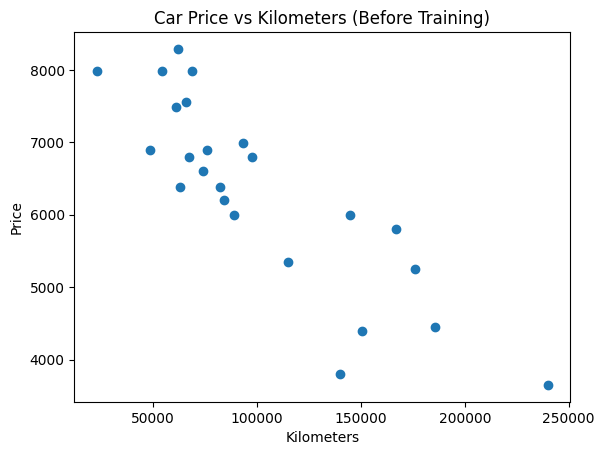

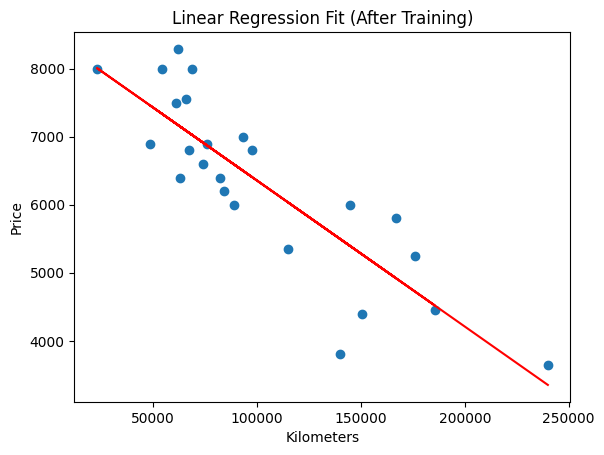

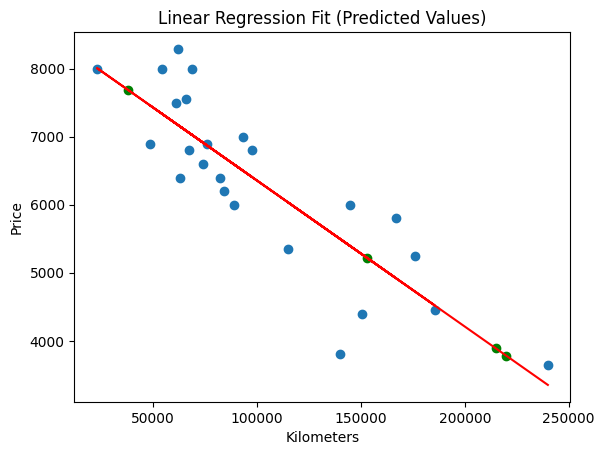

In [6]:
x, y = load_data("./linear-regression-data.csv")
plot_data(x, y, title="Car Price vs Kilometers (Before Training)")
theta = linear_regression_mse(x, y)
plot_data(x, y, theta[0], theta[1], title="Linear Regression Fit (After Training)")
values_to_predict = [153000, 38000, 220000, 215000]
predictions = predict_values(values_to_predict, theta)
plot_data(x, y, theta[0], theta[1], values_to_predict, predictions, title="Linear Regression Fit (Predicted Values)")